In [46]:
import os
os.chdir("/Users/srujansingh/Documents/JeanFan_Lab/Kidney_Structural_Analysis/")

import scanpy as sc
#ctrl1_data only contains the all the tubule annotations:
ctrl1_data = sc.read_h5ad("data/2um/Ctrl_1A2/Ctrl_1A2_visiumhd_2um_proximal_labeled.h5ad")
ctrl1_data.obs.shape 

(5549563, 6)

In [47]:
ctrl1_data.shape #Bins x Genes

(5549563, 19059)

In [48]:
#Importing the geojson files which contains the proximal tubule annotations and boudary information.
import geopandas as gpd
gdf=gpd.read_file("data/2um/geojson/Ctrl_1A2_tubules_processed_caleb.geojson")
gdf.head()
gdf.shape

(11653, 6)

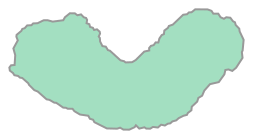

In [49]:
#Sanity Check
tubule=gdf[gdf["id"]=="929"]
geom=tubule.geometry.iloc[0]
geom

In [50]:
ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()

s_002um_00000_02609-1    True
s_002um_00000_02610-1    True
s_002um_00000_02611-1    True
s_002um_00000_02612-1    True
s_002um_00000_02613-1    True
                         ... 
s_002um_03347_00386-1    True
s_002um_03347_00387-1    True
s_002um_03347_00388-1    True
s_002um_03347_00389-1    True
s_002um_03347_00390-1    True
Name: proximal_tubule_geojson_feature_index, Length: 5549563, dtype: bool

In [65]:
#Bootstrapping a few oproximal tubule instances to perform linear regression on:
import pandas as pd
ctrl1_A2_PT=ctrl1_data[~ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()].copy() #removing all the NAs
PT_id=ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].unique()
PT_id_rand=pd.Series(PT_id).sample(n=500, random_state=53) #randomly select 5 proximal tubule (geojson IDs)
print(PT_id_rand.tolist())


[1924, 4644, 876, 441, 4575, 5010, 5739, 5593, 5133, 5643, 4893, 60, 4673, 10339, 414, 4277, 5845, 1679, 3827, 236, 4871, 3307, 1105, 5773, 480, 6460, 2948, 1492, 597, 3584, 1838, 279, 1070, 4304, 9515, 8139, 4169, 2555, 2635, 5282, 791, 7411, 9652, 1123, 1926, 6545, 3051, 5938, 4802, 1519, 2721, 3802, 1738, 6613, 2613, 1616, 2979, 4432, 2628, 1995, 3705, 1629, 4696, 1432, 254, 4880, 4161, 1441, 6220, 1169, 3693, 4527, 4578, 1858, 1527, 4328, 4562, 5481, 9517, 2353, 922, 1557, 2193, 4976, 2837, 3053, 4530, 2570, 5531, 8703, 3374, 3737, 2565, 3494, 971, 2046, 6266, 6467, 5419, 10540, 8039, 612, 2754, 511, 6285, 1027, 6122, 4192, 3761, 9206, 10493, 2645, 1347, 3970, 1253, 1944, 3974, 355, 3156, 168, 3770, 3302, 4612, 4035, 6408, 398, 84, 4793, 10605, 2894, 945, 4614, 3540, 4818, 4039, 337, 1761, 1210, 1209, 4781, 5605, 10507, 1556, 1460, 5930, 3146, 4162, 2400, 1610, 1774, 5205, 5182, 7775, 10100, 1560, 2733, 4558, 1263, 43, 4443, 4042, 2292, 5431, 816, 469, 5600, 4813, 4425, 6130, 7393,

In [66]:
#Convert the five proximal tubules into radial coordinates:
#ctrl1_A2_PT[ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index']==str(PT_id_rand)]
ptoi=PT_id_rand.astype(str).tolist() #proximal tubule of interest
subset=ctrl1_A2_PT[ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].astype(str).isin(ptoi)].copy()
subset.shape #Bins x Genes

(276784, 19059)

In [67]:
#Non dimensionalizing the x and y coordinates
x = subset.obs["pxl_col_in_fullres"]
y = subset.obs["pxl_row_in_fullres"]

#Convert bins to shapely points:
from shapely.geometry import Point
points = [Point(xy) for xy in zip(x, y)]

#Extract the polygon boundary:
boundary = geom.boundary

#Computing distance to edge:
distances = [p.distance(boundary) for p in points]

#Append this new distance matrix into the subset data:
subset.obs["dist_to_edge"] = distances
subset.obs["dist_to_edge"] = subset.obs["dist_to_edge"].values/max(subset.obs["dist_to_edge"].values)
subset.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index,dist_to_edge
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929,0.000013
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929,0.000038
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929,0.000137
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929,0.000073
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929,0.000117
...,...,...,...,...,...,...,...
s_002um_03081_00927-1,1,3081,927,15050.493122,14042.298862,5938,0.818540
s_002um_03081_00928-1,1,3081,928,15050.545696,14037.759889,5938,0.818626
s_002um_03081_00929-1,1,3081,929,15050.598270,14033.220917,5938,0.818713
s_002um_03081_00930-1,1,3081,930,15050.650844,14028.681944,5938,0.818799


In [73]:
#Converting the x and y coordinates into bins (To account for size diiference in different PTs)
import pandas as pd
import numpy as np

# Define bins
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
bins = [0,0.5, 1.0]

subset.obs["dist_bin"] = pd.cut(
    subset.obs["dist_to_edge"],
    bins=bins,
    labels=False,
    include_lowest=True
)
subset.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index,dist_to_edge,dist_bin
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929,0.000013,0
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929,0.000038,0
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929,0.000137,0
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929,0.000073,0
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929,0.000117,0
...,...,...,...,...,...,...,...,...
s_002um_03081_00927-1,1,3081,927,15050.493122,14042.298862,5938,0.818540,1
s_002um_03081_00928-1,1,3081,928,15050.545696,14037.759889,5938,0.818626,1
s_002um_03081_00929-1,1,3081,929,15050.598270,14033.220917,5938,0.818713,1
s_002um_03081_00930-1,1,3081,930,15050.650844,14028.681944,5938,0.818799,1


In [78]:

bin_means = []
bin_centers = []

for b in range(2):
    mask = subset.obs["dist_bin"] == b
    
    if np.sum(mask) == 0:
        continue
    
    X_bin = subset[mask].X
    
    mean_expr = X_bin.mean(axis=0)
    bin_means.append(np.array(mean_expr).flatten())
    
    # use mean distance of that bin
    bin_centers.append(subset.obs.loc[mask, "dist_to_edge"].mean())

bin_means = np.vstack(bin_means)
bin_centers = np.array(bin_centers).reshape(-1, 1)

In [79]:
betas = []

from sklearn.linear_model import LinearRegression
for g in range(bin_means.shape[1]):
    y = bin_means[:, g]
    
    model = LinearRegression().fit(bin_centers, y)
    betas.append(model.coef_[0])

Edge genes:
 ['Kap', 'Ugt3a2', 'Ehhadh', 'Mep1a', 'Cyb5b', 'Cpt2', 'Mep1b', 'Acadm', 'Cyp51', 'Ubr3', 'Asl', 'Aadac', 'Retsat', 'Bdh1', 'Hint2', 'Slc16a9', 'Pdk2', 'Hist1h2bc', 'Gclc', 'Gipc2']

Center genes:
 ['mt-Co2', 'Gpx3', 'mt-Co3', 'mt-Atp6', 'mt-Nd1', 'Acy3', 'Acsm2', 'mt-Co1', 'mt-Cytb', 'mt-Atp8', 'Igfbp7', 'Selenop', 'Slc34a1', 'Fth1', 'mt-Nd5', 'Umod', 'Pck1', 'Aldob', 'mt-Nd4l', 'Atp1b1']


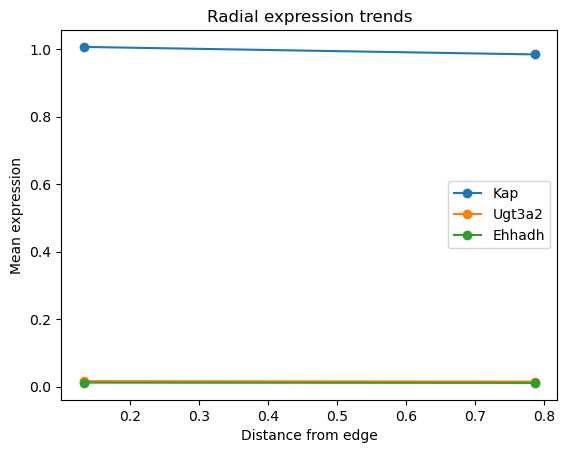

In [81]:
subset.var["dist_slope"] = betas

top_edge = subset.var.sort_values("dist_slope").head(20) #Only selecting the the top 20 genes
top_center = subset.var.sort_values("dist_slope", ascending=False).head(20)

print("Edge genes:\n", top_edge.index.tolist())
print("\nCenter genes:\n", top_center.index.tolist())

import matplotlib.pyplot as plt

genes_to_plot = top_edge.index[:3].tolist() #+ top_center.index[:3].tolist()

for gene in genes_to_plot:
    g_idx = subset.var_names.get_loc(gene)
    
    plt.plot(bin_centers, bin_means[:, g_idx], marker='o', label=gene)

plt.xlabel("Distance from edge")
plt.ylabel("Mean expression")
plt.title("Radial expression trends")
plt.legend()
plt.show()